In [42]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
import japanize_matplotlib
sys.setrecursionlimit(100000000)

In [43]:
# スペック部分
class EVA:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            self.all += 1

            if x <= 1/319.7*0.03:
                self.kaitensuu = 0
                self.balls += 1400
                self.rush()
            elif x <= 1/319.7 * 0.59:
                self.kaitensuu = 0
                self.balls += 420
                self.rush()
            elif x <= 1/319.7:
                self.kaitensuu = 0
                self.balls += 420
                self.short()
    def rush(self):
        x = random.random()
        if x <= 0.809989:
            self.balls += 1400
            self.rush()
        else:
            self.normal()

    def short(self):
        x = np.random.geometric(1/319.9)
        if x <= 104:
            self.balls += 1400
            self.rush()
        else:
            self.normal()


In [44]:
# スペック部分
class GHOUL:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e
        self.min = 0 # 最小弾数
        self.max = 0 # 最大弾数

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit or self.max-self.min>96000:

                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            if self.balls < self.min:
                self.min = self.balls
            self.all += 1

            if x <= 1/199.9 * 0.5:
                self.kaitensuu = 0
                self.balls += 280
                self.normal()
            elif x <= 1/199.9 * 0.505:
                self.kaitensuu = 0
                self.balls += 280
                self.rush()
            elif x <= 1/199.9 * 0.755:
                self.kaitensuu = 0
                self.balls += 1400
                self.rush()
            elif x <= 1/199.9:
                self.kaitensuu = 0
                self.balls += 1400
                self.normal()
    def rush(self):
        x = random.random()
        if x <= 0.7462284263:
            furiwake = random.random()
            if furiwake <= 0.97:
                self.balls += 2800
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
            else:
                self.balls += 5600
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
        else:
            self.normal()


In [45]:
# スペック部分
class UMI:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            self.all += 1

            if x <= 1/319.7*0.4:
                self.kaitensuu = 0
                self.balls += 1400
                self.short()
            elif x <= 1/319.7:
                self.kaitensuu = 0
                self.balls += 1400
                self.rush()
    def rush(self):
        x = random.random()
        if x <= 0.4:
            self.balls += 1400
            self.kaitensuu = 0
            self.short()
        else:
            self.kaitensuu = 0
            self.balls += 1400
            self.rush()


    def short(self):
        x = np.random.geometric(1/319.7)
        if x <= 100:
            furiwake = random.random()
            if furiwake <= 0.4:
                self.balls += 1400
                self.kaitensuu = 0
                self.short()
            else:
                self.balls += 1400
                self.rush()
        else:
            self.normal()


In [46]:
# instance = spec(0, 0, 0, 17, 2000) # 初期化
# balls = instance.normal()
# result.append(balls)


In [47]:
# 1日2000回転のシミュレーション関数
def daily_simulation(machine_class, border=17, spins=2000):
    """
    1日分のシミュレーションを実行
    machine_class: 使用するマシンクラス (EVA, GHOUL, UMI)
    border: 1kあたりの回転数
    spins: 1日の回転数
    """
    instance = machine_class(0, 0, 0, border, spins)
    final_balls = instance.normal()
    return final_balls


In [48]:
# 30日間のシミュレーション実行
def run_30day_simulation(machine_class, border=17, spins=2000):
    """
    30日間のシミュレーションを実行し、日別の収支を記録
    """
    daily_results = []

    print(f"30日間のシミュレーション開始...")
    print(f"マシン: {machine_class.__name__}")
    print(f"1日あたり回転数: {spins}")
    print(f"1kあたり回転数: {border}")
    print("-" * 50)

    for day in tqdm(range(1, 31), desc="シミュレーション進行中"):
        daily_balls = daily_simulation(machine_class, border, spins)
        daily_results.append({
            'day': day,
            'balls': daily_balls,
            'profit_loss': daily_balls  # 出玉 = 収支
        })

    return daily_results


In [49]:
# カレンダー表示用の関数
import matplotlib.patches as patches
from datetime import datetime, timedelta

def create_calendar_visualization(daily_results, machine_name):
    """
    30日間の収支をカレンダー形式で可視化
    """
    fig, ax = plt.subplots(figsize=(15, 10))

    # カレンダーのグリッドを作成 (5週 x 7日)
    weeks = 5
    days_per_week = 7

    # 色の設定
    colors = []
    values = []

    for result in daily_results:
        profit_loss = result['profit_loss']
        values.append(profit_loss)

        # 収支に応じて色を決定
        if profit_loss > 0:
            # プラス（緑系）
            intensity = min(abs(profit_loss) / 1000, 1.0)
            colors.append((0, 0.5 + intensity * 0.5, 0))
        else:
            # マイナス（赤系）
            intensity = min(abs(profit_loss) / 1000, 1.0)
            colors.append((0.5 + intensity * 0.5, 0, 0))

    # カレンダーグリッドを描画
    for i in range(weeks):
        for j in range(days_per_week):
            day_index = i * days_per_week + j

            if day_index < len(daily_results):
                # 四角形を描画
                rect = patches.Rectangle((j, weeks-1-i), 1, 1,
                                       linewidth=2, edgecolor='black',
                                       facecolor=colors[day_index])
                ax.add_patch(rect)

                # 日付と収支を表示
                day = daily_results[day_index]['day']
                profit_loss = daily_results[day_index]['profit_loss']

                                # テキストの色を決定（背景に応じて）
                if profit_loss > 0:
                    # 緑背景には黒文字
                    text_color = 'black'
                else:
                    # 赤背景には白文字
                    text_color = 'white'

                ax.text(j + 0.5, weeks-1-i + 0.7, f"{day}日",
                       ha='center', va='center', fontsize=14, fontweight='bold',
                       color=text_color)
                ax.text(j + 0.5, weeks-1-i + 0.3, f"{profit_loss:.0f}",
                       ha='center', va='center', fontsize=12,
                       color=text_color)

    # 軸の設定
    ax.set_xlim(0, days_per_week)
    ax.set_ylim(0, weeks)
    ax.set_xticks(range(days_per_week))
    ax.set_xticklabels(['月', '火', '水', '木', '金', '土', '日'])
    ax.set_yticks(range(weeks))
    ax.set_yticklabels([f'第{i+1}週' for i in range(weeks)])

    # タイトルとラベル
    ax.set_title(f'{machine_name} - 30日間収支カレンダー\n(1日2000回転)',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('曜日', fontsize=12)
    ax.set_ylabel('週', fontsize=12)

    # 凡例
    legend_elements = [
        patches.Patch(color='green', label='プラス収支'),
        patches.Patch(color='red', label='マイナス収支')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()


In [50]:
# 統計情報表示関数
def display_statistics(daily_results, machine_name):
    """
    30日間の統計情報を表示
    """
    profits = [result['profit_loss'] for result in daily_results]

    print(f"\n=== {machine_name} 30日間統計情報 ===")
    print(f"総回転数: {len(daily_results) * 2000:,}回転")
    print(f"総収支: {sum(profits):,.0f}玉")
    print(f"平均日収支: {np.mean(profits):,.0f}玉")
    print(f"最大日収支: {max(profits):,.0f}玉")
    print(f"最小日収支: {min(profits):,.0f}玉")
    print(f"標準偏差: {np.std(profits):,.0f}玉")

    # プラス日数とマイナス日数
    positive_days = sum(1 for p in profits if p > 0)
    negative_days = sum(1 for p in profits if p < 0)
    zero_days = sum(1 for p in profits if p == 0)

    print(f"\n収支別日数:")
    print(f"プラス日数: {positive_days}日 ({positive_days/30*100:.1f}%)")
    print(f"マイナス日数: {negative_days}日 ({negative_days/30*100:.1f}%)")
    print(f"ゼロ日数: {zero_days}日 ({zero_days/30*100:.1f}%)")

    # 連続プラス/マイナス日数の最大値
    max_consecutive_positive = 0
    max_consecutive_negative = 0
    current_positive = 0
    current_negative = 0

    for profit in profits:
        if profit > 0:
            current_positive += 1
            current_negative = 0
            max_consecutive_positive = max(max_consecutive_positive, current_positive)
        elif profit < 0:
            current_negative += 1
            current_positive = 0
            max_consecutive_negative = max(max_consecutive_negative, current_negative)
        else:
            current_positive = 0
            current_negative = 0

    print(f"\n連続記録:")
    print(f"最大連続プラス日数: {max_consecutive_positive}日")
    print(f"最大連続マイナス日数: {max_consecutive_negative}日")


In [2]:
# メイン実行部分 - EVAマシンでシミュレーション実行
print("EVAマシンで30日間シミュレーションを開始します...")
border = 20
spins = 900
eva_results = run_30day_simulation(EVA, border=border, spins=spins)

# 統計情報を表示
display_statistics(eva_results, "EVA")
# 期待値
print(spins*(border-16.5)*250/16.5)

# カレンダーを表示
create_calendar_visualization(eva_results, "EVA")


EVAマシンで30日間シミュレーションを開始します...


NameError: name 'run_30day_simulation' is not defined


GHOULマシンで30日間シミュレーションを開始します...
30日間のシミュレーション開始...
マシン: GHOUL
1日あたり回転数: 6000
1kあたり回転数: 16.8
--------------------------------------------------


シミュレーション進行中: 100%|██████████| 30/30 [00:00<00:00, 832.71it/s]


=== GHOUL 30日間統計情報 ===
総回転数: 60,000回転
総収支: -62,839玉
平均日収支: -2,095玉
最大日収支: 95,285玉
最小日収支: -69,701玉
標準偏差: 40,610玉

収支別日数:
プラス日数: 14日 (46.7%)
マイナス日数: 16日 (53.3%)
ゼロ日数: 0日 (0.0%)

連続記録:
最大連続プラス日数: 3日
最大連続マイナス日数: 4日


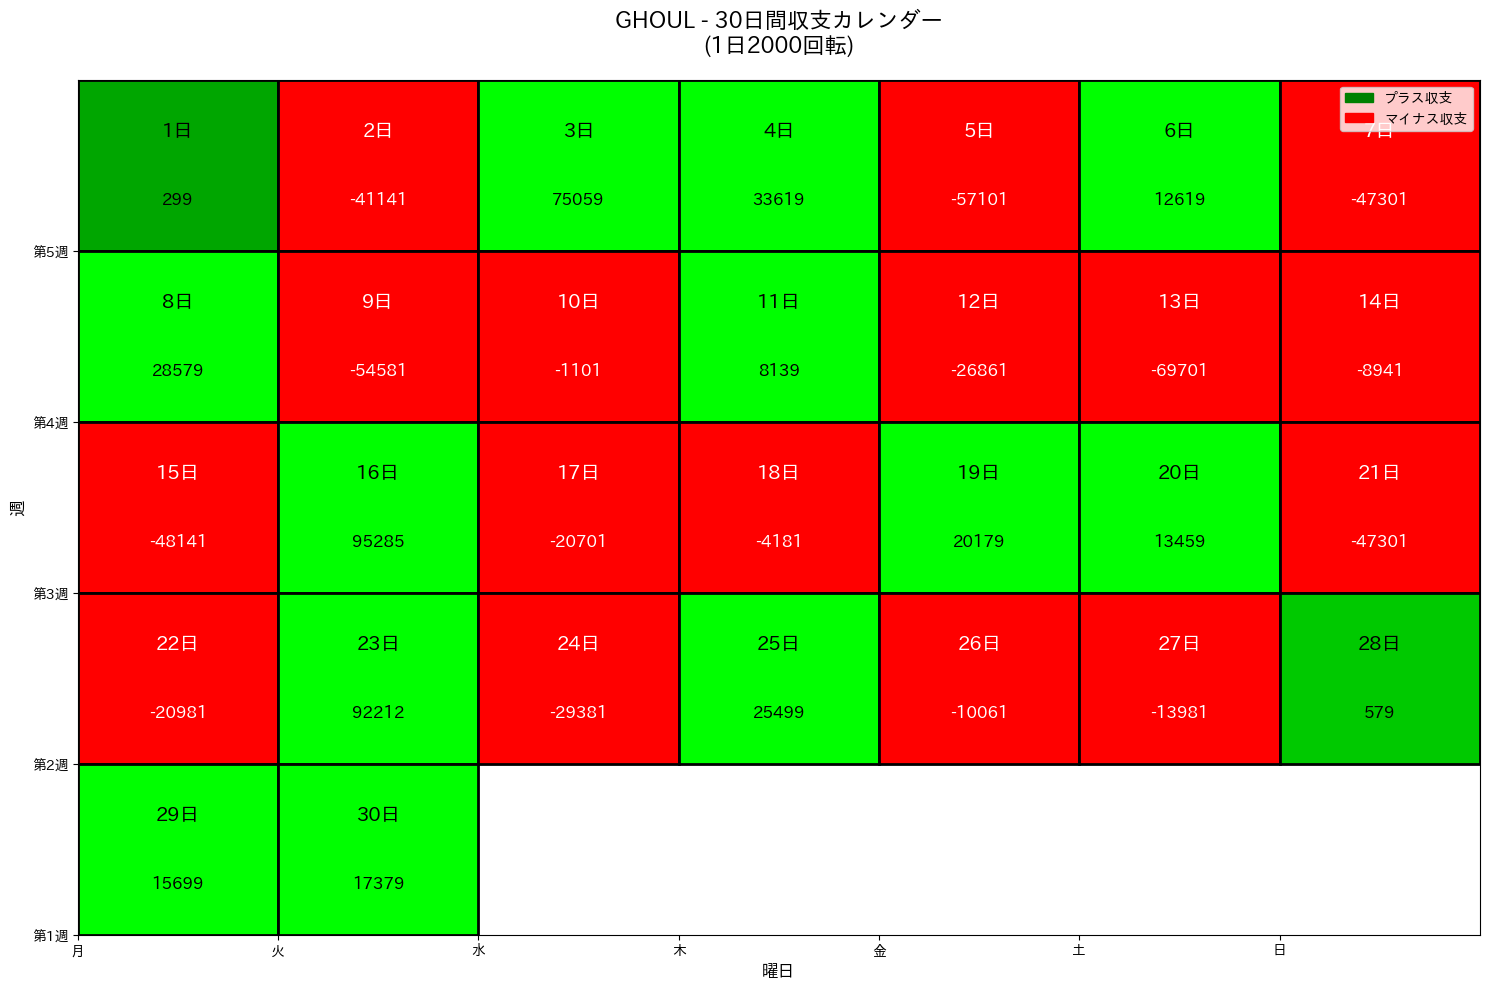

In [ ]:
# 他のマシンでもシミュレーション実行（オプション）
print("\n" + "="*60)
print("GHOULマシンで30日間シミュレーションを開始します...")
ghoul_results = run_30day_simulation(GHOUL, border=16.8, spins=900)

# 統計情報を表示
display_statistics(ghoul_results, "GHOUL")

# カレンダーを表示
create_calendar_visualization(ghoul_results, "GHOUL")


In [1]:
# UMIマシンでもシミュレーション実行（オプション）
print("\n" + "="*60)
print("UMIマシンで30日間シミュレーションを開始します...")
umi_results = run_30day_simulation(UMI, border=17, spins=900)

# 統計情報を表示
display_statistics(umi_results, "UMI")

# カレンダーを表示
create_calendar_visualization(umi_results, "UMI")



UMIマシンで30日間シミュレーションを開始します...


NameError: name 'run_30day_simulation' is not defined

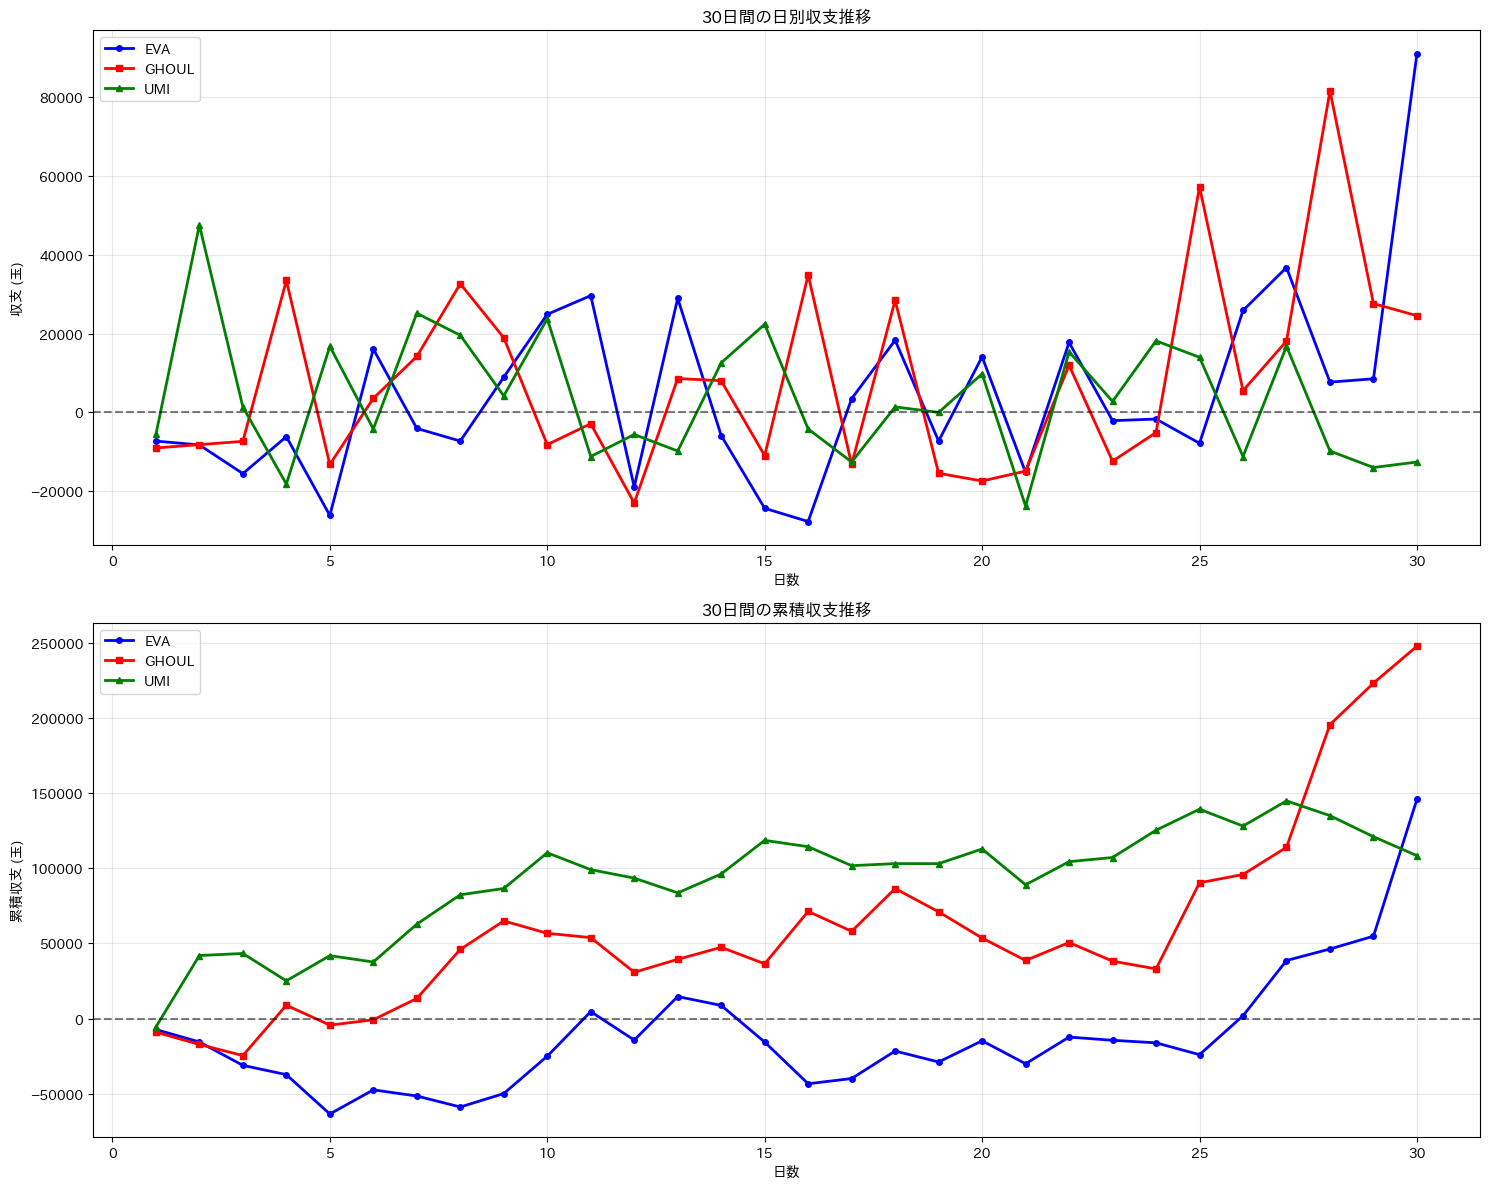


=== マシン比較結果 ===
EVA   最終収支: 145,926玉
GHOUL 最終収支: 247,825玉
UMI   最終収支: 108,406玉


In [54]:
# マシン比較用のグラフ
def compare_machines(eva_results, ghoul_results, umi_results):
    """
    3つのマシンの結果を比較するグラフを作成
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

    # 日別収支の推移
    days = list(range(1, 31))
    eva_profits = [r['profit_loss'] for r in eva_results]
    ghoul_profits = [r['profit_loss'] for r in ghoul_results]
    umi_profits = [r['profit_loss'] for r in umi_results]

    ax1.plot(days, eva_profits, 'b-', label='EVA', linewidth=2, marker='o', markersize=4)
    ax1.plot(days, ghoul_profits, 'r-', label='GHOUL', linewidth=2, marker='s', markersize=4)
    ax1.plot(days, umi_profits, 'g-', label='UMI', linewidth=2, marker='^', markersize=4)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.set_xlabel('日数')
    ax1.set_ylabel('収支 (玉)')
    ax1.set_title('30日間の日別収支推移')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 累積収支の推移
    eva_cumulative = np.cumsum(eva_profits)
    ghoul_cumulative = np.cumsum(ghoul_profits)
    umi_cumulative = np.cumsum(umi_profits)

    ax2.plot(days, eva_cumulative, 'b-', label='EVA', linewidth=2, marker='o', markersize=4)
    ax2.plot(days, ghoul_cumulative, 'r-', label='GHOUL', linewidth=2, marker='s', markersize=4)
    ax2.plot(days, umi_cumulative, 'g-', label='UMI', linewidth=2, marker='^', markersize=4)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.set_xlabel('日数')
    ax2.set_ylabel('累積収支 (玉)')
    ax2.set_title('30日間の累積収支推移')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 最終結果の比較
    print("\n=== マシン比較結果 ===")
    print(f"EVA   最終収支: {eva_cumulative[-1]:,.0f}玉")
    print(f"GHOUL 最終収支: {ghoul_cumulative[-1]:,.0f}玉")
    print(f"UMI   最終収支: {umi_cumulative[-1]:,.0f}玉")

# マシン比較を実行
compare_machines(eva_results, ghoul_results, umi_results)
